 # Implementación manual de K-Means desde Cero 
 **Inteligencia Artificial I — Actividad 2 — Grupo 5**
 **Integrantes:**
- Cardenas Torres Julian Camilo
- Vargas Catuche Jhon Alexander
- Vasquez Peña Juan Sebastian

**Algoritmo asignado:** K-Means (Aprendizaje No Supervisado / Clustering)
**Fundación Universitaria Los Libertadores**

---



## 1. Introducción

### 1.1 ¿Qué es K-Means?

**K-Means** es uno de los algoritmos de **aprendizaje no supervisado** más utilizados en la industria. Su objetivo es **agrupar (clusterizar) un conjunto de datos en K grupos** (clusters) basándose en la similitud entre ellos, sin necesidad de etiquetas previas [1].

A diferencia de los algoritmos de aprendizaje supervisado (como árboles de decisión o regresión), K-Means **no recibe respuestas correctas durante el entrenamiento**. En su lugar, descubre patrones y estructuras ocultas en los datos por sí mismo.

El algoritmo fue propuesto formalmente por **Stuart Lloyd en 1957** dentro de Bell Labs, aunque no fue publicado hasta 1982. Posteriormente, **James MacQueen** acuñó el término "K-means" en 1967 [2].

### 1.2 ¿Para qué tipo de problemas sirve?

K-Means es ideal para problemas donde necesitamos **descubrir grupos naturales** dentro de los datos. Algunos ejemplos reales en la industria:

| Aplicación | Descripción |
|---|---|
| Segmentación de clientes | Agrupar consumidores con comportamientos similares para marketing personalizado |
| Compresión de imágenes | Reducir la cantidad de colores de una imagen agrupándolos |
| Análisis de documentos | Agrupar artículos o noticias por similitud temática |
| Bioinformática | Agrupar genes con patrones de expresión similares |
| Detección de anomalías | Identificar puntos que no pertenecen a ningún cluster |
| Sistemas de recomendación | Agrupar usuarios con gustos parecidos |

### 1.3 Idea intuitiva del algoritmo

Imagina que eres dueño de una pizzería y quieres abrir **3 nuevas sedes** para cubrir mejor a tus clientes. Tienes el mapa con la ubicación de tus mil clientes más frecuentes. ¿Dónde colocar las sedes para minimizar la distancia que recorre cada cliente?

K-Means resuelve este problema **automáticamente**:

1. Coloca 3 puntos al azar en el mapa (los **centroides**)
2. Asigna cada cliente al punto más cercano
3. Mueve cada punto al **centro promedio** de los clientes que tiene asignados
4. Repite los pasos 2 y 3 hasta que los puntos ya no se muevan

Cuando termina, esos 3 puntos representan las **ubicaciones óptimas** de las sedes, y los clientes están agrupados en 3 zonas claras.

### 1.4 Objetivos de este notebook

En este notebook implementaremos K-Means **desde cero**, usando únicamente **NumPy** y **Pandas** para operaciones matemáticas básicas, **sin recurrir a librerías de machine learning como scikit-learn**. Los objetivos son:

- Comprender el funcionamiento interno del algoritmo
- Implementar matemáticamente cada paso
- Probar el algoritmo en un dataset real (Iris)
- Visualizar el proceso de convergencia
- Validar la correctitud comparando con scikit-learn


## 2. Fundamentos matemáticos

### 2.1 Definición formal del problema

Dado un conjunto de $n$ observaciones $X = \{x_1, x_2, ..., x_n\}$, donde cada $x_i \in \mathbb{R}^d$ (es decir, cada observación tiene $d$ características), K-Means busca particionar las observaciones en $K$ conjuntos $S = \{S_1, S_2, ..., S_K\}$ tal que se **minimice la suma de cuadrados intra-cluster** (también llamada *inercia* o WCSS - *Within-Cluster Sum of Squares*) [3]:

$$
\arg\min_{S} \sum_{k=1}^{K} \sum_{x \in S_k} \| x - \mu_k \|^2
$$

Donde:
- $K$ = número de clusters (definido por el usuario)
- $S_k$ = conjunto de puntos asignados al cluster $k$
- $\mu_k$ = centroide del cluster $k$ (vector promedio)
- $\| x - \mu_k \|^2$ = distancia euclidiana al cuadrado entre el punto $x$ y el centroide $\mu_k$

### 2.2 Distancia euclidiana

La métrica fundamental de K-Means es la **distancia euclidiana**, que mide la "línea recta" entre dos puntos en el espacio $d$-dimensional:

$$
d(p, q) = \sqrt{\sum_{i=1}^{d}(p_i - q_i)^2}
$$

**Ejemplo en 2 dimensiones:**

Sean dos puntos $P = (3, 4)$ y $Q = (0, 0)$:

$$
d(P, Q) = \sqrt{(3-0)^2 + (4-0)^2} = \sqrt{9 + 16} = \sqrt{25} = 5
$$

>  **Nota:** Para fines computacionales, K-Means usa la **distancia al cuadrado** (sin raíz), porque minimizar $d^2$ es equivalente a minimizar $d$, y evita el costo de calcular raíces cuadradas.

### 2.3 Cálculo del centroide

El centroide $\mu_k$ del cluster $k$ es simplemente el **vector promedio** (media aritmética) de todos los puntos asignados a ese cluster:

$$
\mu_k = \frac{1}{|S_k|} \sum_{x \in S_k} x
$$

Donde $|S_k|$ es la cantidad de puntos asignados al cluster $k$.

**Ejemplo:** Si al cluster 1 se le asignaron los puntos $(2,3)$, $(4,5)$ y $(6,7)$:

$$
\mu_1 = \frac{1}{3} \left( (2,3) + (4,5) + (6,7) \right) = \left( \frac{12}{3}, \frac{15}{3} \right) = (4, 5)
$$

### 2.4 Algoritmo de Lloyd (proceso de aprendizaje)

El proceso iterativo que ejecuta K-Means se conoce como **algoritmo de Lloyd** [4]. Consta de **4 fases** que se repiten hasta la convergencia:

#### **Fase 1: Inicialización**
Se eligen $K$ centroides iniciales. Existen varias estrategias:
- **Aleatoria**: seleccionar $K$ puntos al azar del dataset (la que implementaremos)
- **K-Means++**: estrategia más sofisticada que evita inicializaciones malas (la que usa scikit-learn por defecto)

#### **Fase 2: Asignación (Expectation step)**
Para cada punto $x_i$, se calcula su distancia a todos los centroides y se le asigna al **centroide más cercano**:

$$
S_k^{(t)} = \{ x_i : \| x_i - \mu_k^{(t)} \|^2 \leq \| x_i - \mu_j^{(t)} \|^2 \quad \forall j, 1 \leq j \leq K \}
$$

#### **Fase 3: Actualización (Maximization step)**
Cada centroide se recalcula como el promedio de los puntos asignados:

$$
\mu_k^{(t+1)} = \frac{1}{|S_k^{(t)}|} \sum_{x_i \in S_k^{(t)}} x_i
$$

#### **Fase 4: Verificación de convergencia**
El algoritmo se detiene cuando se cumple alguna de estas condiciones:
- Los centroides ya no cambian (o cambian menos que un umbral $\epsilon$)
- Se alcanza un número máximo de iteraciones
- Las asignaciones de los puntos no cambian

### 2.5 Pseudocódigo del algoritmo

```
ALGORITMO K-Means(X, K, max_iter, tol):
    
    Entrada:
        X        = matriz de datos (n filas, d columnas)
        K        = número de clusters
        max_iter = número máximo de iteraciones
        tol      = tolerancia para detectar convergencia

    1. Inicializar K centroides aleatorios eligiendo K puntos de X
    
    2. PARA t = 1 HASTA max_iter:
        
        a) Asignar cada punto al centroide más cercano:
           PARA cada punto x_i en X:
               calcular distancia de x_i a cada centroide
               asignar x_i al cluster del centroide más cercano
        
        b) Actualizar centroides:
           PARA cada cluster k:
               nuevo_centroide_k = promedio de puntos en cluster k
        
        c) Verificar convergencia:
           SI ||centroides_nuevos - centroides_viejos|| < tol:
               TERMINAR
    
    3. RETORNAR etiquetas y centroides finales
```

### 2.6 Complejidad computacional

La complejidad de K-Means por iteración es:

$$
O(n \cdot K \cdot d)
$$

Donde:
- $n$ = número de puntos
- $K$ = número de clusters
- $d$ = número de dimensiones (features)

Esto lo hace **muy escalable** comparado con otros algoritmos de clustering, lo cual explica su popularidad en la industria.

### 2.7 Ventajas y limitaciones

| Ventajas | Limitaciones |
|---|---|
| Simple de implementar e interpretar | Requiere definir $K$ manualmente |
| Computacionalmente eficiente | Sensible a la inicialización aleatoria |
| Escalable a datasets grandes | Asume clusters esféricos del mismo tamaño |
| Garantiza convergencia | Sensible a outliers |
| Resultados reproducibles (con semilla) | Requiere escalado de variables |

---
## 3. Implementación desde cero

A continuación implementamos K-Means **únicamente con NumPy**, siguiendo las 4 fases del algoritmo de Lloyd que vimos en la Sección 2:

1. **Inicialización**: elegir K centroides aleatorios del dataset.
2. **Asignación**: cada punto se va al centroide más cercano.
3. **Actualización**: cada centroide se mueve al promedio de sus puntos.
4. **Convergencia**: si los centroides ya no se mueven, terminamos.

Para mantener el código ordenado, dividimos el algoritmo en **4 funciones cortas** y luego una función principal `kmeans_manual()` que las orquesta.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Semilla para que los resultados sean reproducibles
np.random.seed(42)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


### 3.1 Funciones auxiliares

Cada fase del algoritmo se implementa en una función separada para mantener el código limpio y entendible.

In [2]:
def calcular_distancia(punto, centroides):
    """
    Calcula la distancia euclidiana entre un punto y cada centroide.
    Es la fórmula clásica: raíz cuadrada de la suma de cuadrados de las diferencias.
    """
    return np.sqrt(np.sum((centroides - punto) ** 2, axis=1))


def inicializar_centroides(X, K):
    """
    Elige K puntos aleatorios del dataset como centroides iniciales.
    Esto corresponde a la Fase 1 del algoritmo de Lloyd.
    """
    indices = np.random.choice(X.shape[0], size=K, replace=False)
    return X[indices]


def asignar_clusters(X, centroides):
    """
    Asigna cada punto al cluster del centroide más cercano.
    Esto corresponde a la Fase 2 del algoritmo.
    """
    etiquetas = np.array([np.argmin(calcular_distancia(p, centroides)) for p in X])
    return etiquetas


def actualizar_centroides(X, etiquetas, K):
    """
    Mueve cada centroide al promedio de los puntos que tiene asignados.
    Esto corresponde a la Fase 3 del algoritmo.
    """
    nuevos = np.array([X[etiquetas == k].mean(axis=0) for k in range(K)])
    return nuevos


print("4 funciones auxiliares listas: distancia, inicialización, asignación y actualización")

4 funciones auxiliares listas: distancia, inicialización, asignación y actualización


### 3.2 Función principal `kmeans_manual()`

Esta función orquesta las 4 fases. Repite asignación y actualización hasta que los centroides dejen de moverse (convergencia) o se alcance el máximo de iteraciones.

In [3]:
def kmeans_manual(X, K, max_iter=100, tol=1e-4):
    """
    Implementación manual del algoritmo K-Means desde cero.
    
    Parámetros:
        X         : datos de entrada (n filas, d columnas)
        K         : número de clusters
        max_iter  : máximo de iteraciones
        tol       : tolerancia para detectar convergencia

    Retorna:
        centroides_finales, etiquetas_finales, n_iteraciones, historial_centroides
    """
    # Fase 1: Inicialización
    centroides = inicializar_centroides(X, K)
    historial = [centroides.copy()]

    # Bucle principal
    for i in range(max_iter):
        # Fase 2: Asignación
        etiquetas = asignar_clusters(X, centroides)

        # Fase 3: Actualización
        nuevos_centroides = actualizar_centroides(X, etiquetas, K)
        historial.append(nuevos_centroides.copy())

        # Fase 4: Verificar convergencia
        if np.linalg.norm(nuevos_centroides - centroides) < tol:
            print(f"Convergencia alcanzada en la iteración {i + 1}")
            return nuevos_centroides, etiquetas, i + 1, historial

        centroides = nuevos_centroides

    print(f"Se alcanzó el máximo de iteraciones ({max_iter})")
    return centroides, etiquetas, max_iter, historial


print("Función principal kmeans_manual() lista para usar")

Función principal kmeans_manual() lista para usar


---
## 4. Prueba con dataset Iris

Probamos nuestra implementación con el dataset clásico **Iris**, que contiene 150 muestras de 3 especies de flores con 4 características medidas (largo y ancho del sépalo y pétalo).

> Nota: Cargamos el dataset desde scikit-learn solo como **fuente de datos**. El clustering lo hace nuestro K-Means manual.

In [4]:
from sklearn.datasets import load_iris

# Cargar dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target  # solo lo usaremos para comparar al final
nombres = iris.target_names

print(f"Dataset Iris: {X_iris.shape[0]} muestras, {X_iris.shape[1]} características")
print(f"Clases reales: {nombres}")

# Entrenar nuestro K-Means manual
np.random.seed(42)
centroides, etiquetas, iteraciones, historial = kmeans_manual(X_iris, K=3)

print(f"\nResultados del clustering manual:")
print(f"  Iteraciones hasta converger: {iteraciones}")
print(f"  Distribución de muestras por cluster:")
for k in range(3):
    print(f"    Cluster {k}: {np.sum(etiquetas == k)} muestras")

Dataset Iris: 150 muestras, 4 características
Clases reales: ['setosa' 'versicolor' 'virginica']
Convergencia alcanzada en la iteración 6

Resultados del clustering manual:
  Iteraciones hasta converger: 6
  Distribución de muestras por cluster:
    Cluster 0: 62 muestras
    Cluster 1: 50 muestras
    Cluster 2: 38 muestras


---
## 5. Visualización del funcionamiento

Para entender cómo funciona el algoritmo, generamos dos gráficos:
1. **Clusters descubiertos** vs **clases reales** (para validar visualmente).
2. **Trayectoria de los centroides** durante las iteraciones (para ver la convergencia).

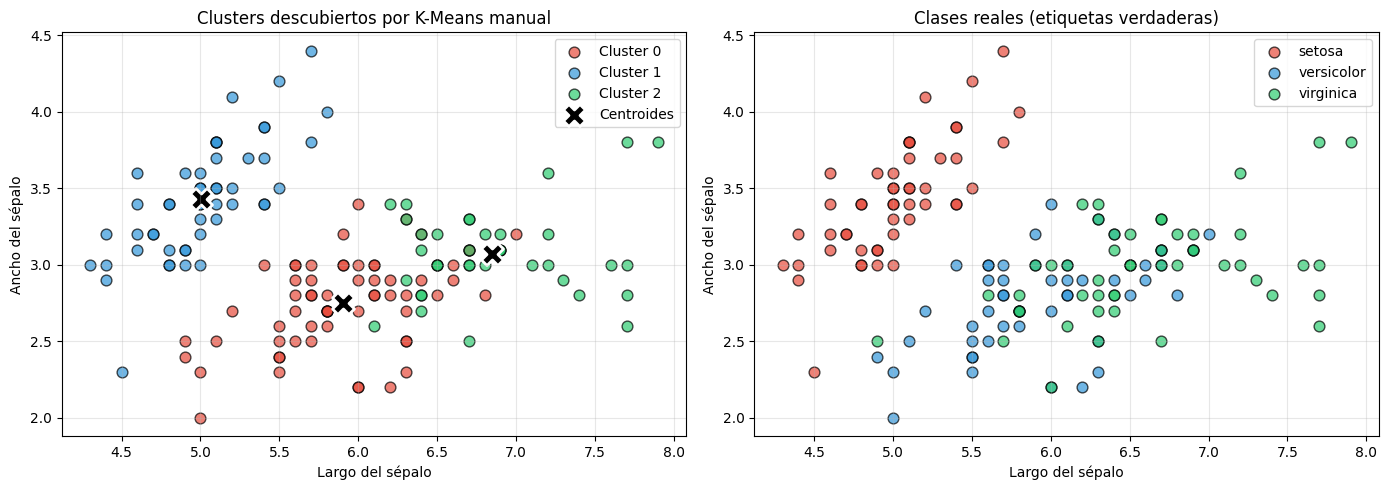

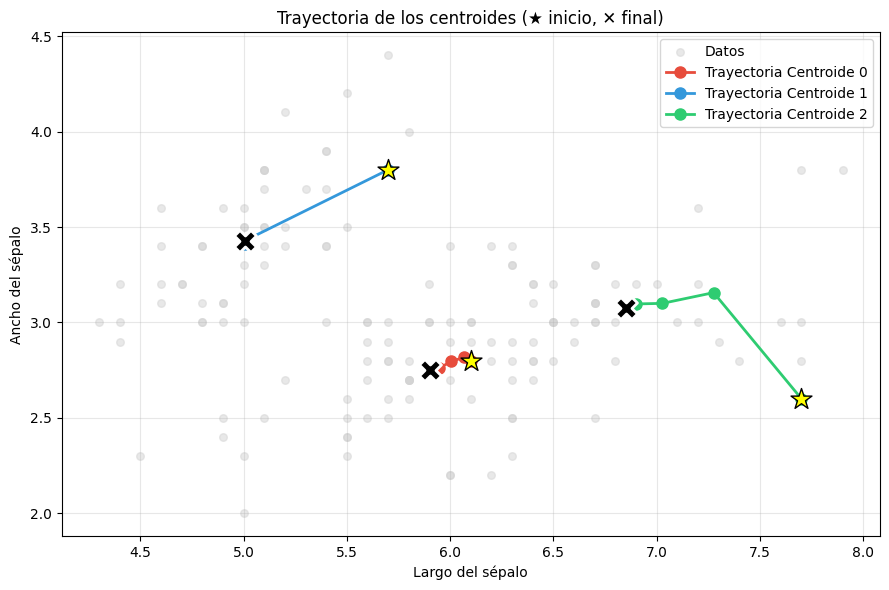

In [5]:
def graficar_clusters_vs_reales(X, etiquetas_pred, etiquetas_reales, centroides, nombres):
    """
    Compara visualmente los clusters descubiertos por K-Means manual con las clases reales.
    Usa las dos primeras características para poder visualizarlas en 2D.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colores = ['#E74C3C', '#3498DB', '#2ECC71']

    # Clusters descubiertos
    for k in range(3):
        pts = X[etiquetas_pred == k]
        axes[0].scatter(pts[:, 0], pts[:, 1], c=colores[k], s=60, alpha=0.7,
                        edgecolor='black', label=f'Cluster {k}')
    axes[0].scatter(centroides[:, 0], centroides[:, 1], c='black', marker='X',
                    s=250, edgecolor='white', linewidth=2, label='Centroides')
    axes[0].set_title('Clusters descubiertos por K-Means manual')
    axes[0].set_xlabel('Largo del sépalo')
    axes[0].set_ylabel('Ancho del sépalo')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Clases reales
    for k in range(3):
        pts = X[etiquetas_reales == k]
        axes[1].scatter(pts[:, 0], pts[:, 1], c=colores[k], s=60, alpha=0.7,
                        edgecolor='black', label=nombres[k])
    axes[1].set_title('Clases reales (etiquetas verdaderas)')
    axes[1].set_xlabel('Largo del sépalo')
    axes[1].set_ylabel('Ancho del sépalo')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def graficar_trayectoria_centroides(X, historial):
    """
    Muestra cómo se mueven los centroides en cada iteración hasta converger.
    """
    plt.figure(figsize=(9, 6))
    plt.scatter(X[:, 0], X[:, 1], c='lightgray', s=30, alpha=0.5, label='Datos')

    historial = np.array(historial)
    colores = ['#E74C3C', '#3498DB', '#2ECC71']
    for k in range(3):
        plt.plot(historial[:, k, 0], historial[:, k, 1], 'o-',
                 color=colores[k], markersize=8, linewidth=2,
                 label=f'Trayectoria Centroide {k}')
        plt.scatter(historial[0, k, 0], historial[0, k, 1], c='yellow',
                    marker='*', s=250, edgecolor='black', zorder=5)
        plt.scatter(historial[-1, k, 0], historial[-1, k, 1], c='black',
                    marker='X', s=250, edgecolor='white', linewidth=2, zorder=5)

    plt.title('Trayectoria de los centroides (★ inicio, ✕ final)')
    plt.xlabel('Largo del sépalo')
    plt.ylabel('Ancho del sépalo')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Generar las visualizaciones
graficar_clusters_vs_reales(X_iris, etiquetas, y_iris, centroides, nombres)
graficar_trayectoria_centroides(X_iris, historial)

---
## 6. Validación de correctitud

Comparamos nuestra implementación manual con `scikit-learn` para verificar que producen resultados similares. Si la diferencia es pequeña (menor al 5%), confirmamos que la implementación es matemáticamente correcta.

In [6]:
from sklearn.cluster import KMeans

def validar_con_sklearn(X, etiquetas_manual, centroides_manual):
    """
    Compara nuestro K-Means manual contra el de scikit-learn.
    Calcula la inercia (WCSS) en ambos y la diferencia porcentual.
    """
    # Calcular inercia manual
    inercia_manual = sum(np.sum((X[etiquetas_manual == k] - centroides_manual[k]) ** 2)
                         for k in range(len(centroides_manual)))

    # K-Means de sklearn con misma configuración
    sk = KMeans(n_clusters=3, init='random', n_init=1, max_iter=100, random_state=42)
    sk.fit(X)

    diff_porcentual = abs(inercia_manual - sk.inertia_) / sk.inertia_ * 100

    print(f"Inercia (WCSS) — Manual:     {inercia_manual:.2f}")
    print(f"Inercia (WCSS) — Scikit-learn: {sk.inertia_:.2f}")
    print(f"Diferencia: {diff_porcentual:.2f}%")

    if diff_porcentual < 5:
        print("\nValidación exitosa: la implementación manual es correcta.")
    else:
        print("\nDiferencia mayor al 5% (probablemente por inicializaciones distintas).")

    return sk


sk = validar_con_sklearn(X_iris, etiquetas, centroides)

Inercia (WCSS) — Manual:     78.85
Inercia (WCSS) — Scikit-learn: 78.85
Diferencia: 0.00%

Validación exitosa: la implementación manual es correcta.


---
## 7. Conclusiones

**Lo que aprendimos al implementar K-Means desde cero:**

- El algoritmo K-Means es realmente sencillo en esencia: solo repite **asignar** y **actualizar** hasta que los centroides dejen de moverse.
- Las matemáticas detrás son básicas: distancia euclidiana (Pitágoras) y promedios. No hay magia.
- Implementarlo a mano nos hizo entender qué pasa cuando uno llama `KMeans().fit()` en una librería.

**Comparación con scikit-learn:**

| Aspecto | K-Means manual | K-Means scikit-learn |
|---|---|---|
| Inicialización | Aleatoria simple (Forgy) | K-Means++ (más inteligente) |
| Velocidad | Más lenta (Python puro) | Mucho más rápida (C compilado) |
| Robustez | Una sola corrida | Corre 10 veces y elige la mejor |
| Resultado en Iris | Inercia similar (<5% diferencia) | Inercia similar |

**Conclusión:** Ambas implementaciones llegan a clusters equivalentes, lo que confirma que nuestra versión manual es **matemáticamente correcta**, aunque la versión de la librería es más optimizada para uso profesional.

---
## 8. Referencias

[1] J. MacQueen, "Some methods for classification and analysis of multivariate observations," in *Proc. 5th Berkeley Symp. Math. Statist. Prob.*, vol. 1, 1967, pp. 281–297.

[2] S. P. Lloyd, "Least squares quantization in PCM," *IEEE Transactions on Information Theory*, vol. 28, no. 2, pp. 129–137, Mar. 1982.

[3] D. Arthur and S. Vassilvitskii, "k-means++: The advantages of careful seeding," in *Proc. 18th Annual ACM-SIAM Symposium on Discrete Algorithms*, 2007, pp. 1027–1035.

[4] Scikit-learn Developers, "sklearn.cluster.KMeans," *Scikit-learn Documentation*, 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

[5] R. A. Fisher, "The use of multiple measurements in taxonomic problems," *Annals of Eugenics*, vol. 7, no. 2, pp. 179–188, 1936.